# Lesson 6: Essay Writer

In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

import sqlite3
#memory = SqliteSaver.from_conn_string(":memory:") 
memory = SqliteSaver(sqlite3.connect(":memory:", check_same_thread=False))

/Users/anupamchakraborty/Code/my_exp/building_ai_systems_2026/langraph_agent/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [4]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

In [5]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [6]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [7]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [8]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


In [9]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [10]:
#from langchain_core.pydantic_v1 import BaseModel
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [11]:
from tavily import TavilyClient
import os
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [12]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [13]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    #content = state['content'] or []
    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [14]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [15]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [16]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [17]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [18]:
builder = StateGraph(AgentState)

In [19]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [20]:
builder.set_entry_point("planner")

In [21]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)


In [22]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [23]:
graph = builder.compile(checkpointer=memory)
#graph = builder.compile()

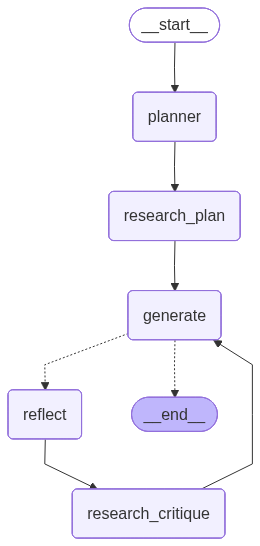

In [24]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [29]:
thread = {"configurable": {"thread_id": "1"}}
graph.invoke({"task": "what is the difference between langchain and langsmith", 
              "max_revisions": 2, 
              "revision_number": 1}, thread)

/Users/anupamchakraborty/Code/my_exp/building_ai_systems_2026/langraph_agent/.venv/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:2381: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


{'task': 'what is the difference between langchain and langsmith',
 'plan': 'I. Introduction\n    A. Brief overview of Langchain and Langsmith\n    B. Thesis statement: Exploring the differences between Langchain and Langsmith\n\nII. Langchain\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIII. Langsmith\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIV. Comparison between Langchain and Langsmith\n    A. Technology stack\n    B. Scalability\n    C. Security\n    D. Interoperability\n    E. Performance\n\nV. Conclusion\n    A. Recap of main differences between Langchain and Langsmith\n    B. Implications for future development and adoption\n    C. Final thoughts on the significance of these technologies\n\nNotes:\n- Ensure to provide clear definitions and explanations of both Langch

In [28]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)

{'planner': {'plan': 'I. Introduction\n    A. Brief overview of Langchain and Langsmith\n    B. Thesis statement: Exploring the differences between Langchain and Langsmith\n\nII. Langchain\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIII. Langsmith\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIV. Comparison between Langchain and Langsmith\n    A. Technology stack\n    B. Scalability\n    C. Security\n    D. Interoperability\n    E. Performance\n\nV. Conclusion\n    A. Recap of main points\n    B. Implications of the differences between Langchain and Langsmith\n    C. Future outlook for both technologies\n\nNotes:\n- Ensure to provide clear definitions and explanations for both Langchain and Langsmith.\n- Include specific examples of use cases and applications for each technolog

/Users/anupamchakraborty/Code/my_exp/building_ai_systems_2026/langraph_agent/.venv/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:2381: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


{'research_plan': {'content': ['If you’re responsible for ensuring your AI models work in production, or you need to frequently debug and monitor your pipelines, Langsmith is your go-to tool. In short, while **Langchain** excels at managing and scaling model workflows, **Langsmith** is designed for those times when you need deep visibility and control over large, complex AI systems in production. But if you’re managing a **complex AI pipeline** with multiple models that need debugging and orchestrating, Langsmith’s capabilities become essential. However, if you’re dealing with **large-scale production environments** that require deep monitoring, performance tuning, and orchestration across various models and platforms, Langsmith’s more advanced architecture will handle your needs better. If you’re debugging complex AI models or managing large-scale workflows with multiple moving parts, **Langsmith’s advanced debugging and orchestration features** will be indispensable. Choosing between

## Essay Writer Interface

In [30]:
import warnings
warnings.filterwarnings("ignore", message=".*TqdmWarning.*")
from dotenv import load_dotenv

_ = load_dotenv()

from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from langchain_openai import ChatOpenAI
#from langchain_core.pydantic_v1 import BaseModel
from pydantic import BaseModel
from tavily import TavilyClient
import os
import sqlite3

class AgentState(TypedDict):
    task: str
    lnode: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    queries: List[str]
    revision_number: int
    max_revisions: int
    count: Annotated[int, operator.add]


class Queries(BaseModel):
    queries: List[str]
    
class ewriter():
    def __init__(self):
        self.model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
        self.PLAN_PROMPT = ("You are an expert writer tasked with writing a high level outline of a short 3 paragraph essay. "
                            "Write such an outline for the user provided topic. Give the three main headers of an outline of "
                             "the essay along with any relevant notes or instructions for the sections. ")
        self.WRITER_PROMPT = ("You are an essay assistant tasked with writing excellent 3 paragraph essays. "
                              "Generate the best essay possible for the user's request and the initial outline. "
                              "If the user provides critique, respond with a revised version of your previous attempts. "
                              "Utilize all the information below as needed: \n"
                              "------\n"
                              "{content}")
        self.RESEARCH_PLAN_PROMPT = ("You are a researcher charged with providing information that can "
                                     "be used when writing the following essay. Generate a list of search "
                                     "queries that will gather "
                                     "any relevant information. Only generate 3 queries max.")
        self.REFLECTION_PROMPT = ("You are a teacher grading an 3 paragraph essay submission. "
                                  "Generate critique and recommendations for the user's submission. "
                                  "Provide detailed recommendations, including requests for length, depth, style, etc.")
        self.RESEARCH_CRITIQUE_PROMPT = ("You are a researcher charged with providing information that can "
                                         "be used when making any requested revisions (as outlined below). "
                                         "Generate a list of search queries that will gather any relevant information. "
                                         "Only generate 2 queries max.")
        self.tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
        builder = StateGraph(AgentState)
        builder.add_node("planner", self.plan_node)
        builder.add_node("research_plan", self.research_plan_node)
        builder.add_node("generate", self.generation_node)
        builder.add_node("reflect", self.reflection_node)
        builder.add_node("research_critique", self.research_critique_node)
        builder.set_entry_point("planner")
        builder.add_conditional_edges(
            "generate", 
            self.should_continue, 
            {END: END, "reflect": "reflect"}
        )
        builder.add_edge("planner", "research_plan")
        builder.add_edge("research_plan", "generate")
        builder.add_edge("reflect", "research_critique")
        builder.add_edge("research_critique", "generate")
        memory = SqliteSaver(conn=sqlite3.connect(":memory:", check_same_thread=False))
        self.graph = builder.compile(
            checkpointer=memory,
            interrupt_after=['planner', 'generate', 'reflect', 'research_plan', 'research_critique']
        )


    def plan_node(self, state: AgentState):
        messages = [
            SystemMessage(content=self.PLAN_PROMPT), 
            HumanMessage(content=state['task'])
        ]
        response = self.model.invoke(messages)
        return {"plan": response.content,
               "lnode": "planner",
                "count": 1,
               }
    def research_plan_node(self, state: AgentState):
        queries = self.model.with_structured_output(Queries).invoke([
            SystemMessage(content=self.RESEARCH_PLAN_PROMPT),
            HumanMessage(content=state['task'])
        ])
        content = state['content'] or []  # add to content
        for q in queries.queries:
            response = self.tavily.search(query=q, max_results=2)
            for r in response['results']:
                content.append(r['content'])
        return {"content": content,
                "queries": queries.queries,
               "lnode": "research_plan",
                "count": 1,
               }
    def generation_node(self, state: AgentState):
        content = "\n\n".join(state['content'] or [])
        user_message = HumanMessage(
            content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
        messages = [
            SystemMessage(
                content=self.WRITER_PROMPT.format(content=content)
            ),
            user_message
            ]
        response = self.model.invoke(messages)
        return {
            "draft": response.content, 
            "revision_number": state.get("revision_number", 1) + 1,
            "lnode": "generate",
            "count": 1,
        }
    def reflection_node(self, state: AgentState):
        messages = [
            SystemMessage(content=self.REFLECTION_PROMPT), 
            HumanMessage(content=state['draft'])
        ]
        response = self.model.invoke(messages)
        return {"critique": response.content,
               "lnode": "reflect",
                "count": 1,
        }
    def research_critique_node(self, state: AgentState):
        queries = self.model.with_structured_output(Queries).invoke([
            SystemMessage(content=self.RESEARCH_CRITIQUE_PROMPT),
            HumanMessage(content=state['critique'])
        ])
        content = state['content'] or []
        for q in queries.queries:
            response = self.tavily.search(query=q, max_results=2)
            for r in response['results']:
                content.append(r['content'])
        return {"content": content,
               "lnode": "research_critique",
                "count": 1,
        }
    def should_continue(self, state):
        if state["revision_number"] > state["max_revisions"]:
            return END
        return "reflect"
    
    def run(self, task, max_revisions=2):
        thread = {"configurable": {"thread_id": "1"}}
        for s in self.graph.stream({
            'task': task,
            "max_revisions": max_revisions,
            "revision_number": 1,
        }, thread):
            print(s)

In [31]:
MultiAgent = ewriter()
MultiAgent.run("What are the benefits and drawbacks of using AI in education?", max_revisions=2)

{'planner': {'plan': 'I. Introduction\n- Brief overview of AI in education\n- Thesis statement outlining the benefits and drawbacks of using AI in education\n\nII. Benefits of using AI in education\n- Personalized learning experiences for students\n- Improved efficiency in grading and feedback\n- Access to a wide range of educational resources and tools\n\nIII. Drawbacks of using AI in education\n- Potential job displacement for teachers\n- Privacy and data security concerns\n- Lack of emotional intelligence and human interaction in learning', 'lnode': 'planner', 'count': 1}}
{'__interrupt__': ()}
